In [1]:
# 타이타닉 호 승객 생존 예측 미니 프로젝트 : 1. 분석 & 시각화 -> 2. 전처리 -> (ML) 

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# 한글깨짐 해결, 원인:디폴트 영문글꼴 ==> 한글글꼴
import matplotlib.pyplot as plt
import platform
os_name = platform.system()
if os_name == 'Windows': # 윈도우이면, W:대문자
    plt.rcParams['font.family'] = 'Malgun Gothic' # 맑은 고딕, M,G:대문자, 스페이스 한칸
elif os_name == 'Darwin': # 맥이면, D:대문자
    plt.rcParams['font.family'] = 'AppleGothic'
else: # 리눅스
    plt.rcParams['font.family'] = 'NanumGothic'
# -(마이너스 기호) 깨짐 방지 코드
plt.rcParams['axes.unicode_minus'] = False

In [5]:
df = pd.read_csv('titanic_ok.csv') # 전처리 완료된 CSV 파일 읽기
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,sex2
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",0
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",1
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1303,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN,1
1304,3,0,"Zabour, Miss. Thamine",female,29.8000,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN,1
1305,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN,0
1306,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1308 entries, 0 to 1307
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1308 non-null   int64  
 1   survived   1308 non-null   int64  
 2   name       1308 non-null   object 
 3   sex        1308 non-null   object 
 4   age        1308 non-null   float64
 5   sibsp      1308 non-null   int64  
 6   parch      1308 non-null   int64  
 7   ticket     1308 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1306 non-null   object 
 11  boat       486 non-null    object 
 12  body       120 non-null    float64
 13  home.dest  745 non-null    object 
 14  sex2       1308 non-null   int64  
dtypes: float64(3), int64(5), object(7)
memory usage: 153.4+ KB


In [7]:
# 데이터(X)와 정답(y)를 얻는다.

In [8]:
# X 를 얻는다.
# [ 선실등급, 성별, 나이, 형제_수, 부모_수, 운임 ]
x_cols = [ 'pclass', 'sex2', 'age', 'sibsp', 'parch', 'fare' ]
X = df[x_cols].values # numpy 배열로 리턴
X

array([[  1.    ,   1.    ,  29.    ,   0.    ,   0.    , 211.3375],
       [  1.    ,   0.    ,   0.9167,   1.    ,   2.    , 151.55  ],
       [  1.    ,   1.    ,   2.    ,   1.    ,   2.    , 151.55  ],
       ...,
       [  3.    ,   0.    ,  26.5   ,   0.    ,   0.    ,   7.225 ],
       [  3.    ,   0.    ,  27.    ,   0.    ,   0.    ,   7.225 ],
       [  3.    ,   0.    ,  29.    ,   0.    ,   0.    ,   7.875 ]],
      shape=(1308, 6))

In [9]:
# y를 얻는다.
y = df['survived'].values
y

array([1, 1, 0, ..., 0, 0, 0], shape=(1308,))

In [10]:
# ML 코딩 5단계
# 1. 훈련 데이터와 테스트 데이터로 나눈다.
# 2. ML 알고리즘 선택
# 3. 훈련 : model.fit(...)
# 4. 평가 : model.score(...)
# 5. 새로운 데이터로 예측한다. : model.predit(...)

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
# 훈련_데이터, 테스트_데이터, 훈련_정답, 테스트_정답 = 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=7)

In [13]:
from sklearn.tree import DecisionTreeClassifier

In [14]:
model = DecisionTreeClassifier() # 붕어빵 = 틀()

In [15]:
model.fit(X_train, y_train) # 홍길동.공부해(문제지, 답안지)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [16]:
print("훈련 점수:", model.score(X_train, y_train))
print("테스트 점수:", model.score(X_test, y_test))

훈련 점수: 0.9702633814783348
테스트 점수: 0.7862595419847328


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=7)
model = DecisionTreeClassifier(max_depth=6) # 튜닝
model.fit(X_train, y_train)
print("훈련 점수:", model.score(X_train, y_train))
print("테스트 점수:", model.score(X_test, y_test))

훈련 점수: 0.8300764655904843
테스트 점수: 0.8396946564885496


In [18]:
# 디카프리오는 살 수 있었나?
# [[ 3등실, 남:0, 나이:19살, 형제:0, 부모:0, 운임:9달러 ]]
dicaprio = [[ 3, 0, 19, 0, 0, 9 ]]
result = model.predict_proba(dicaprio)
print(result) # [[0.85858586 0.14141414]] ==> [[ 사망확률 생존확률 ]]
print(f"생존확률:{result[0][1]*100:.2f}%")

[[0.85858586 0.14141414]]
생존확률:14.14%


In [19]:
# 여주인공 윈슬릿은?
# [[ 1등실, 여:1, 나이:17살, 형제:1, 부모:2, 운임:100달러 ]]
winslet = [[ 1, 1, 17, 1, 2, 100 ]]
result = model.predict_proba(winslet)
print(result) # [[0.00787402 0.99212598]] ==> [[ 사망확률 생존확률 ]]
print(f"생존확률:{result[0][1]*100:.2f}%")

[[0.00787402 0.99212598]]
생존확률:99.21%


In [20]:
# 설명 가능한 인공지능 : XAI

In [21]:
from sklearn.tree import plot_tree

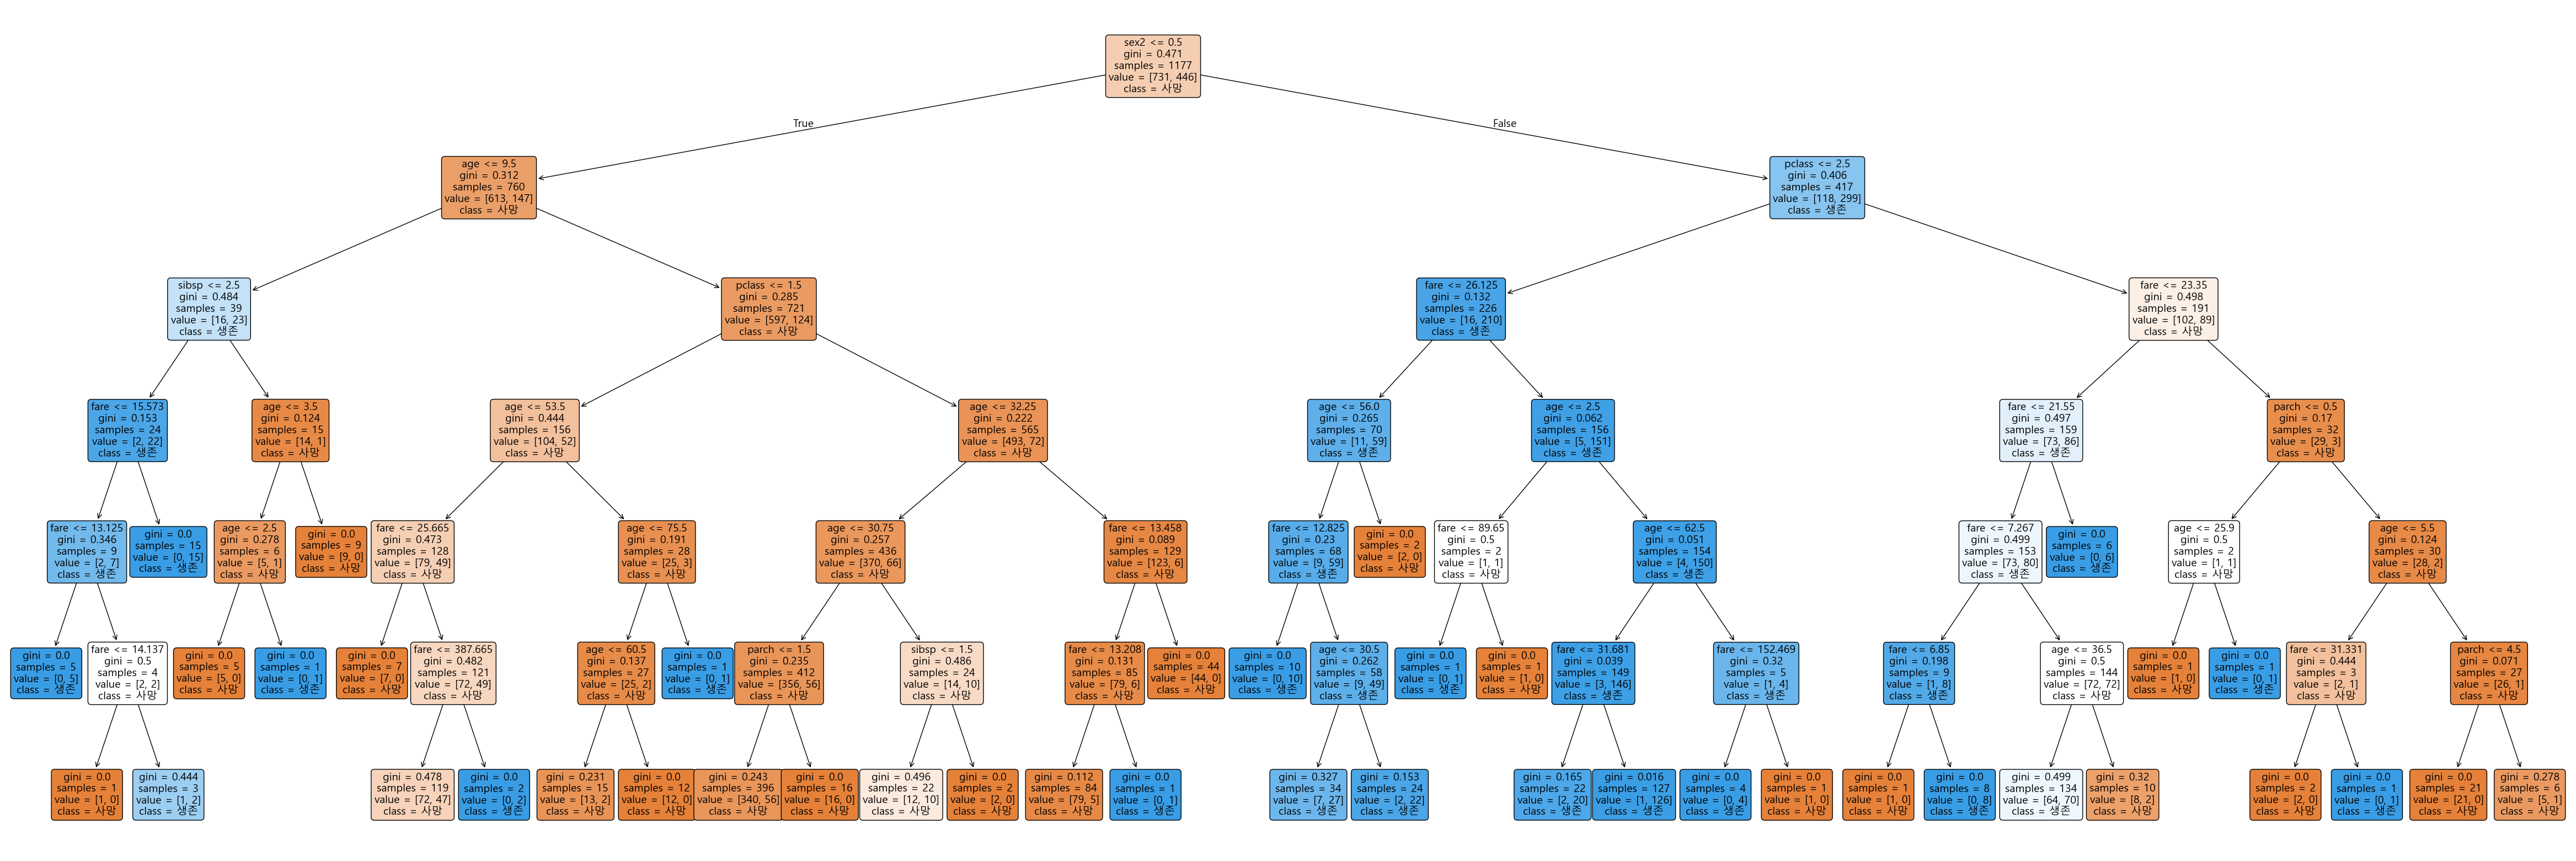

In [22]:
plt.figure(figsize=(60,20))
plot_tree(model, feature_names=x_cols, class_names=['사망','생존'],
         filled=True, rounded=True, fontsize=14)
plt.savefig('tree1.png')
plt.show()

In [23]:
# 중요도 확인
print(x_cols)
print(model.feature_importances_)

['pclass', 'sex2', 'age', 'sibsp', 'parch', 'fare']
[0.19312573 0.52040251 0.1194328  0.04968498 0.00556385 0.11179014]


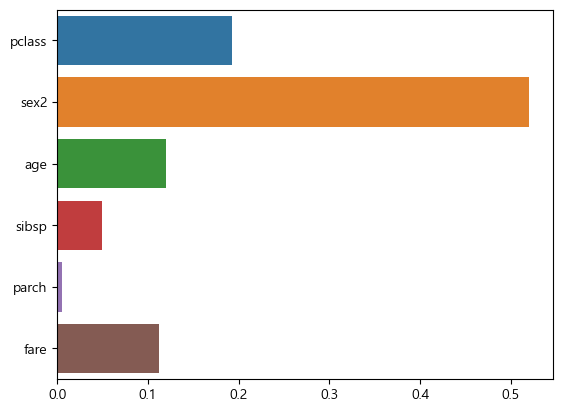

In [24]:
sns.barplot(x=model.feature_importances_, y=x_cols, palette='tab10')
plt.show()

In [25]:
f_imp = pd.Series(model.feature_importances_, index=x_cols).sort_values(ascending=False)
f_imp

sex2      0.520403
pclass    0.193126
age       0.119433
fare      0.111790
sibsp     0.049685
parch     0.005564
dtype: float64

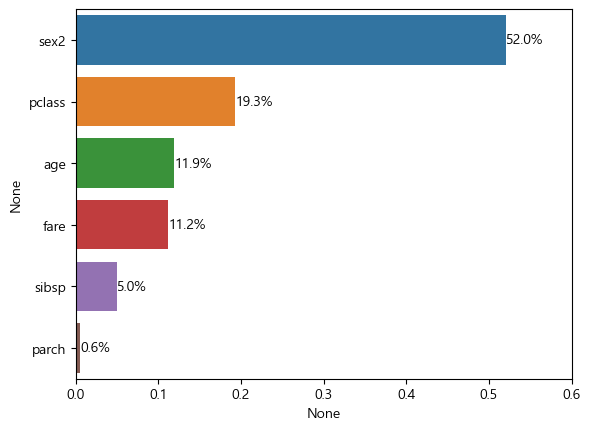

In [26]:
ax = sns.barplot(x=f_imp, y=f_imp.index, palette='tab10')
for i in ax.containers:
    ax.bar_label(i, fmt="{:.1%}")
plt.xlim(0, 0.6)
plt.show()

In [27]:
# end